<a href="https://colab.research.google.com/github/Kubojah-Dan/kuboja-codeboosters-2026/blob/main/DAY5/Project2(Kubo%26Dharnish).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests

In [ ]:
API_KEY="1ac1dc5b28d10b496c6a1d6a4651d5cf"

BASE_URL="https://api.openweathermap.org/data/2.5/weather"

CITIES = ['Mumbai','Delhi','Bengaluru','Chennai','Hyderabad','Kolkata','Pune',"Jaipur", 'Ahmedabad', 'Surat', 'Lucknow', 'Kanpur', 'Nagpur', 'Visakhapatnam', 'Indore', 'Thane', 'Bhopal', 'Patna', 'Vadodara', 'Ghaziabad']

print(f"API configured for {len(CITIES)} cities")
print(f"Cities: {CITIES}")

API configured for 20 cities
Cities: ['Mumbai', 'Delhi', 'Bengaluru', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur', 'Ahmedabad', 'Surat', 'Lucknow', 'Kanpur', 'Nagpur', 'Visakhapatnam', 'Indore', 'Thane', 'Bhopal', 'Patna', 'Vadodara', 'Ghaziabad']


In [ ]:
def fetch_weather(city, api_key):
  """
  Fetch current weather data for a given city.
  Returns a dictionary with weather metrics, or None on failure.
  """

  params = {
      'q' : city,
      'appid' : api_key,
      'units' : 'metric'
  }
  try:
    response = requests.get(BASE_URL, params=params, timeout=10)
    response.raise_for_status()
    data = response.json()
    return {
        'city' : data['name'],
        'feels_like': round(data['main']['feels_like'], 1),
        'icon' : data['weather'][0]['icon'],
        'description' : data['weather'][0]['description'],
        'temperature' : round(data['main']['temp'], 1),
        'humidity' : data['main']['humidity'],
        'wind_speed' : data['wind']['speed'],
    }
  except requests.exceptions.RequestException as e:
    print(f"Error fetching weather data for {city}: {e}")

  except requests.exceptions.Timeout:
    print(f"Timeout fetching weather data for {city}")

  except requests.exceptions.HTTPError as e:
    print(f"HTTP error fetching weather data for {city}: {e}")

print("Calling Weather API....")
weather_records = []

for city in CITIES:
  print(f' Fetching: {city}...', end='')
  weather_data = fetch_weather(city, API_KEY)
  if weather_data:
    weather_records.append(weather_data)
    print(weather_data)

print(f"Successfully Fetched: {len(weather_records)}")

Calling Weather API....
 Fetching: Mumbai...{'city': 'Mumbai', 'feels_like': 41.0, 'icon': '50d', 'description': 'haze', 'temperature': 34.0, 'humidity': 59, 'wind_speed': 9.26}
 Fetching: Delhi...{'city': 'Delhi', 'feels_like': 36.2, 'icon': '02d', 'description': 'few clouds', 'temperature': 35.0, 'humidity': 36, 'wind_speed': 3.09}
 Fetching: Bengaluru...{'city': 'Bengaluru', 'feels_like': 34.0, 'icon': '03d', 'description': 'scattered clouds', 'temperature': 31.1, 'humidity': 56, 'wind_speed': 4.12}
 Fetching: Chennai...{'city': 'Chennai', 'feels_like': 40.8, 'icon': '03d', 'description': 'scattered clouds', 'temperature': 33.8, 'humidity': 60, 'wind_speed': 4.12}
 Fetching: Hyderabad...{'city': 'Hyderabad', 'feels_like': 37.5, 'icon': '03d', 'description': 'scattered clouds', 'temperature': 37.2, 'humidity': 28, 'wind_speed': 7.2}
 Fetching: Kolkata...{'city': 'Kolkata', 'feels_like': 40.0, 'icon': '50d', 'description': 'haze', 'temperature': 33.0, 'humidity': 62, 'wind_speed': 2.0

In [ ]:
import pandas as pd
import sqlite3

# Convert weather_records to a pandas DataFrame
weather_df = pd.DataFrame(weather_records)

# Save to CSV
csv_filename = 'weather_data.csv'
weather_df.to_csv(csv_filename, index=False)
print(f"Weather data saved to {csv_filename}")

# Save to SQLite
sqlite_filename = 'weather_data.db'
conn = sqlite3.connect(sqlite_filename)
weather_df.to_sql('weather', conn, if_exists='replace', index=False)
print(f"Weather data saved to SQLite database {sqlite_filename} in table 'weather'")

# Query for insights (example: get average temperature)
print("\n--- Querying SQLite for insights ---")
query = "SELECT * FROM weather"
nóng_cities_df = pd.read_sql(query, conn)
print("Cities with temperature above 35°C:")
print(nóng_cities_df)

# Close the connection
conn.close()

Weather data saved to weather_data.csv
Weather data saved to SQLite database weather_data.db in table 'weather'

--- Querying SQLite for insights ---
Cities with temperature above 35°C:
             city  feels_like icon       description  temperature  humidity  \
0          Mumbai        41.0  50d              haze         34.0        59   
1           Delhi        36.2  02d        few clouds         35.0        36   
2       Bengaluru        34.0  03d  scattered clouds         31.1        56   
3         Chennai        40.8  03d  scattered clouds         33.8        60   
4       Hyderabad        37.5  03d  scattered clouds         37.2        28   
5         Kolkata        40.0  50d              haze         33.0        62   
6            Pune        34.6  01d         clear sky         35.2        28   
7          Jaipur        35.1  50d              haze         35.6        28   
8       Ahmedabad        39.0  50d              dust         37.0        34   
9           Surat       


--- Exploratory Data Analysis (EDA) for Weather Data ---

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   city         20 non-null     object 
 1   feels_like   20 non-null     float64
 2   icon         20 non-null     object 
 3   description  20 non-null     object 
 4   temperature  20 non-null     float64
 5   humidity     20 non-null     int64  
 6   wind_speed   20 non-null     float64
dtypes: float64(3), int64(1), object(3)
memory usage: 1.2+ KB

Descriptive Statistics:
       feels_like  temperature   humidity  wind_speed
count   20.000000    20.000000  20.000000   20.000000
mean    38.440000    35.265000  42.650000    5.241500
std      3.327303     2.592352  16.413329    2.150376
min     34.000000    31.100000  15.000000    2.060000
25%     35.550000    33.875000  28.000000    4.120000
50%     38.300000    34.950000  38

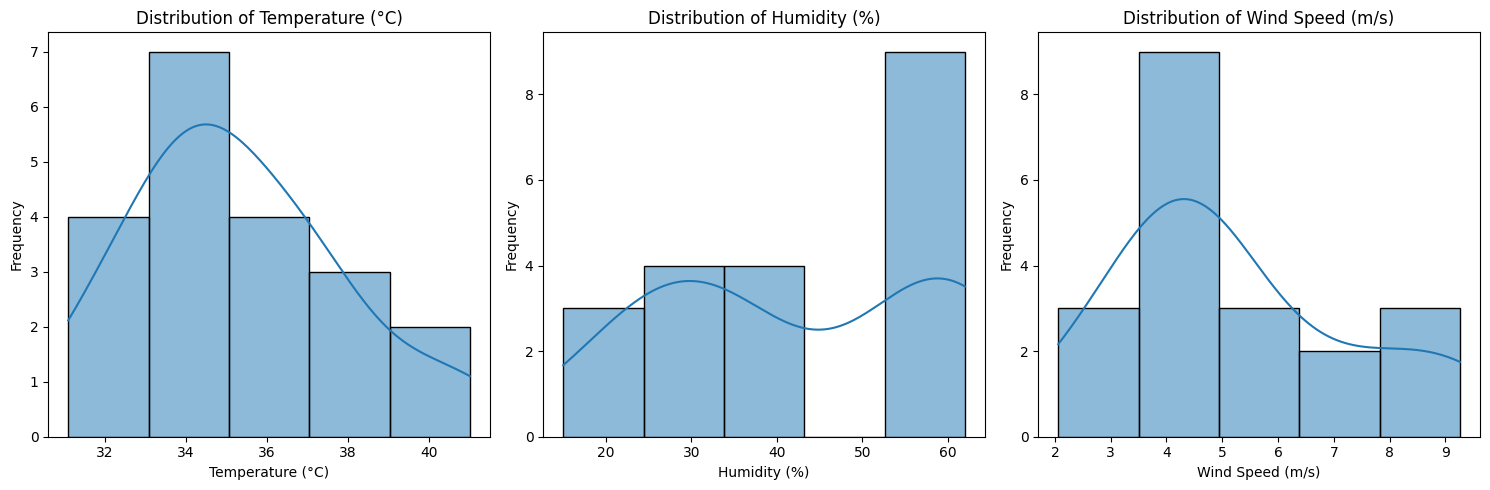

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Exploratory Data Analysis (EDA) for Weather Data ---")

# Display basic information about the DataFrame
print("\nDataFrame Info:")
weather_df.info()

# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
print(weather_df.describe())

# Visualize distributions of numerical features
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(weather_df['temperature'], kde=True, bins=5)
plt.title('Distribution of Temperature (°C)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(weather_df['humidity'], kde=True, bins=5)
plt.title('Distribution of Humidity (%)')
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(weather_df['wind_speed'], kde=True, bins=5)
plt.title('Distribution of Wind Speed (m/s)')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

/tmp/ipykernel_5643/677086555.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city', y='temperature', data=weather_df, palette='coolwarm')
/tmp/ipykernel_5643/677086555.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city', y='humidity', data=weather_df, palette='viridis')
/tmp/ipykernel_5643/677086555.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city', y='wind_speed', data=weather_df, palette='plasma')


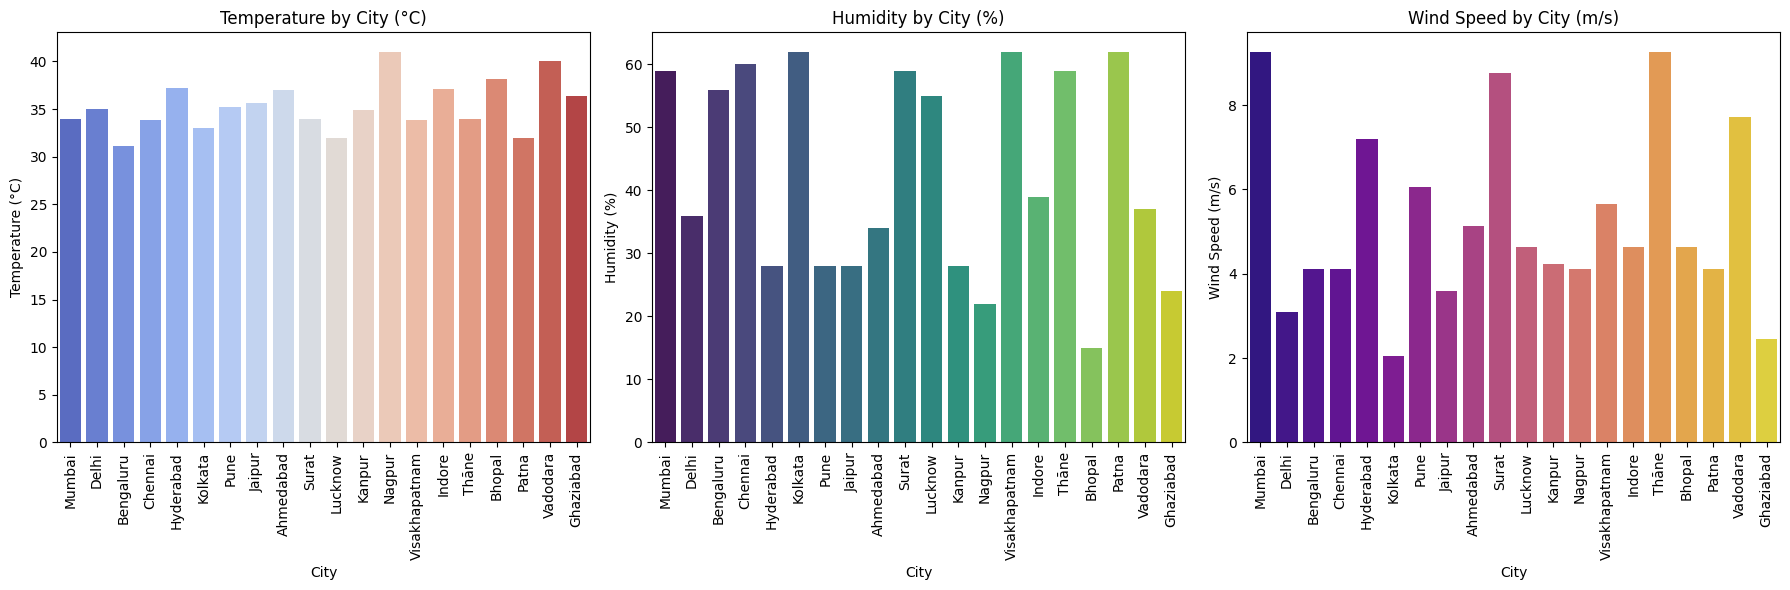

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 6))

# Temperature Chart
plt.subplot(1, 3, 1)
sns.barplot(x='city', y='temperature', data=weather_df, palette='coolwarm')
plt.xticks(rotation=90)
plt.title('Temperature by City (°C)')
plt.xlabel('City')
plt.ylabel('Temperature (°C)')

# Humidity Chart
plt.subplot(1, 3, 2)
sns.barplot(x='city', y='humidity', data=weather_df, palette='viridis')
plt.xticks(rotation=90)
plt.title('Humidity by City (%)')
plt.xlabel('City')
plt.ylabel('Humidity (%)')

# Wind Speed Chart
plt.subplot(1, 3, 3)
sns.barplot(x='city', y='wind_speed', data=weather_df, palette='plasma')
plt.xticks(rotation=90)
plt.title('Wind Speed by City (m/s)')
plt.xlabel('City')
plt.ylabel('Wind Speed (m/s)')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define features (X) and target (y)
X = weather_df[['wind_speed', 'temperature']]
y = weather_df['humidity']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Linear Regression Model Evaluation ---")
print(f"Model Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")



--- Linear Regression Model Evaluation ---
Model Coefficients: [ 2.02707182 -4.6548342 ]
Model Intercept: 195.70691020542216
Mean Absolute Error (MAE): 3.88
Mean Squared Error (MSE): 18.10
R-squared (R2): 0.83
